In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q /content/drive/MyDrive/dataset/Dataset.zip -d /content/drive/MyDrive/Dataset_fast/

replace /content/drive/MyDrive/Dataset_fast/Dataset/testing_set/Heart/heart (101).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/Dataset_fast/Dataset/testing_set/Heart/heart (102).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.6 MB/s eta 0:00:00


In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
"""
Face Shape Classification - YOLO CLASSIFICATION
"""

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import torch
import numpy as np
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shutil
import yaml
from sklearn.model_selection import train_test_split


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# ============================================
# 1. التهيئة (إعداد المسارات)
# ============================================
ORIGINAL_TRAIN_DIR = r"/content/drive/MyDrive/Dataset_fast/Dataset/training_set"
TEST_DIR = r"/content/drive/MyDrive/Dataset_fast/Dataset/testing_set"

PROCESSED_DIR = "yolo_face_dataset"
CLASS_NAMES = ["Heart", "Oblong", "Oval", "Round", "Square"]

if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)

for split in ['train', 'val', 'test']:
    for class_name in CLASS_NAMES:
        os.makedirs(os.path.join(PROCESSED_DIR, split, class_name), exist_ok=True)

print("YOLO Classification Mode Active")
print(f"Training on: {ORIGINAL_TRAIN_DIR}")
print(f"Classes: {CLASS_NAMES}")


YOLO Classification Mode Active
Training on: /content/drive/MyDrive/Dataset_fast/Dataset/training_set
Classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']


In [ ]:
# ============================================
# 2. تقسيم البيانات (Train/Val بنسبة 80/20)
# ============================================
print("\nPreparing dataset for YOLO...")

for class_name in CLASS_NAMES:
    class_path = os.path.join(ORIGINAL_TRAIN_DIR, class_name)
    if not os.path.exists(class_path):
        print(f"Warning: {class_path} not found!")
        continue

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    for img in train_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(PROCESSED_DIR, 'train', class_name, img)
        shutil.copy2(src, dst)

    for img in val_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(PROCESSED_DIR, 'val', class_name, img)
        shutil.copy2(src, dst)

    print(f"  {class_name}: {len(train_imgs)} train, {len(val_imgs)} val")


Preparing dataset for YOLO...
  Heart: 639 train, 160 val
  Oblong: 639 train, 160 val
  Oval: 638 train, 160 val
  Round: 640 train, 160 val
  Square: 640 train, 160 val


In [ ]:

# ============================================
# 3. نسخ مجلد الاختبار
# ============================================
print("\nCopying test dataset...")
for class_name in CLASS_NAMES:
    class_path = os.path.join(TEST_DIR, class_name)
    if not os.path.exists(class_path):
        continue

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img in images:
        src = os.path.join(class_path, img)
        dst = os.path.join(PROCESSED_DIR, 'test', class_name, img)
        shutil.copy2(src, dst)

    print(f"  {class_name}: {len(images)} test images")


📁 Copying test dataset...
  Heart: 200 test images
  Oblong: 200 test images
  Oval: 200 test images
  Round: 200 test images
  Square: 200 test images


In [ ]:

# ============================================
# 5. تحميل وتدريب YOLO (Classification)
# ============================================

print("\nLoading YOLO model...")
model = YOLO('yolov8m-cls.pt')

print("\nStarting YOLO Training...")
print("   This may take 10-20 minutes depending on your hardware\n")

results = model.train(
    data=PROCESSED_DIR,
    epochs=60,
    imgsz=224,
    batch=32,
    device='0',
    workers=4,
    lr0=0.001,
    patience=10,
    seed=42,
    verbose=True,
    augment=True,
    degrees=15,
    flipud=0.2,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    scale=0.5,
    shear=0.2
)

print("\n✅ Training completed!")
print(f"📁 Model saved to: runs/classify/train/weights/best.pt")




🔄 Loading YOLO model...

📊 Starting YOLO Training...
   This may take 10-20 minutes depending on your hardware

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_face_dataset, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=t

In [ ]:
import glob
import os

completed_trainings = glob.glob('runs/classify/train*')
latest_run = max(completed_trainings, key=os.path.getctime)
best_model_path = os.path.join(latest_run, 'weights/best.pt')

print(f"✨ Auto-detected latest weights at: {best_model_path}")
best_model = YOLO(best_model_path)

✨ Auto-detected latest weights at: runs/classify/train-10/weights/best.pt


In [ ]:

# ============================================
# 6. اختبار النموذج على Validation Set
# ============================================
print("\n" + "="*50)
print("VALIDATION RESULTS")
print("="*50)

val_results = best_model.val(data = PROCESSED_DIR, split='val')
val_acc = val_results.top1
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc:.2%})")



VALIDATION RESULTS
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,769,061 parameters, 0 gradients, 41.6 GFLOPs
train: /content/yolo_face_dataset/train... found 3196 images in 5 classes ✅ 
val: /content/yolo_face_dataset/val... found 800 images in 5 classes ✅ 
test: /content/yolo_face_dataset/test... found 1000 images in 5 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1893.2±312.3 MB/s, size: 267.3 KB)
val: Scanning /content/yolo_face_dataset/val... 800 images, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 239.7Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 50/50 4.6it/s 10.8s
                   all      0.889          1
Speed: 0.3ms preprocess, 2.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Validation Accuracy: 0.8888 (88.88%)


In [ ]:

# ============================================
# 7. اختبار النموذج على Test Set
# ============================================
print("\n" + "="*50)
print("TESTING ON YOUR TEST SET")
print("="*50)

all_preds = []
all_labels = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(PROCESSED_DIR, 'test', class_name)
    if not os.path.exists(class_path):
        continue

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        results = best_model(img_path)

        probs = results[0].probs
        pred_class = probs.top1
        confidence = probs.top1conf.item()

        all_preds.append(pred_class)
        all_labels.append(class_idx)

        if len(all_preds) % 50 == 0:
            print(f"  Processed {len(all_preds)} test images...")

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)



TESTING ON YOUR TEST SET

image 1/1 /content/yolo_face_dataset/test/Heart/heart (648).jpg: 224x224 Heart 1.00, Square 0.00, Round 0.00, Oval 0.00, Oblong 0.00, 6.3ms
Speed: 15.1ms preprocess, 6.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/yolo_face_dataset/test/Heart/heart (135).jpg: 224x224 Heart 1.00, Square 0.00, Oval 0.00, Round 0.00, Oblong 0.00, 6.1ms
Speed: 5.0ms preprocess, 6.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/yolo_face_dataset/test/Heart/heart (156).jpg: 224x224 Round 0.62, Heart 0.27, Oval 0.10, Square 0.01, Oblong 0.00, 6.2ms
Speed: 88.6ms preprocess, 6.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/yolo_face_dataset/test/Heart/heart (597).jpg: 224x224 Round 0.98, Heart 0.02, Square 0.00, Oval 0.00, Oblong 0.00, 6.2ms
Speed: 10.0ms preprocess, 6.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/yol

In [ ]:

# ============================================
# 8. النتائج النهائية
# ============================================
test_acc = np.mean(all_labels == all_preds)
improvement = (test_acc - 0.64) * 100

print("\n" + "="*50)
print("FINAL RESULTS - YOLO CLASSIFICATION")
print("="*50)
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc:.2%})")
print(f"Test Accuracy:       {test_acc:.4f} ({test_acc:.2%})")
print(f"Improvement from 64% baseline: +{improvement:.1f}%")



FINAL RESULTS - YOLO CLASSIFICATION
Validation Accuracy: 0.8888 (88.88%)
Test Accuracy:       0.8550 (85.50%)
Improvement from 64% baseline: +21.5%


In [ ]:

# ============================================
# 9. Classification Report
# ============================================
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(all_labels, all_preds,
                           target_names=CLASS_NAMES, digits=4))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Heart     0.8263    0.8800    0.8523       200
      Oblong     0.8702    0.9050    0.8873       200
        Oval     0.8152    0.7500    0.7812       200
       Round     0.8485    0.8400    0.8442       200
      Square     0.9137    0.9000    0.9068       200

    accuracy                         0.8550      1000
   macro avg     0.8548    0.8550    0.8544      1000
weighted avg     0.8548    0.8550    0.8544      1000



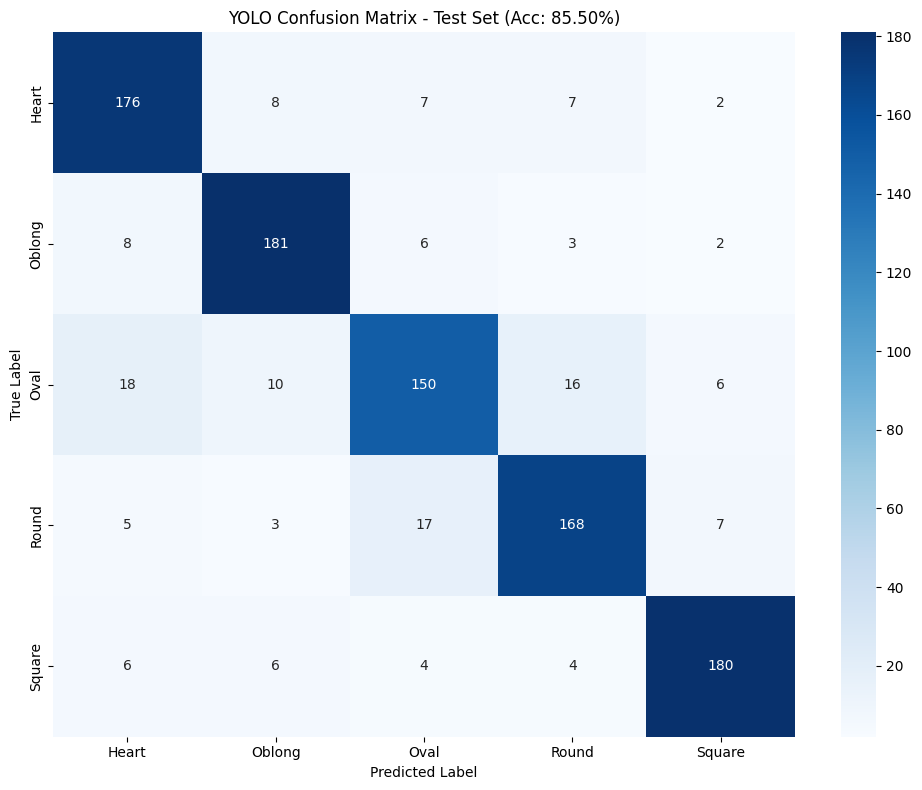

In [ ]:

# ============================================
# 10. Confusion Matrix
# ============================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'YOLO Confusion Matrix - Test Set (Acc: {test_acc:.2%})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('yolo_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:

# ============================================
# 11. ملخص الأداء لكل كلاس
# ============================================
print("\n" + "="*50)
print("PER-CLASS PERFORMANCE")
print("="*50)

for i, class_name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    if mask.sum() > 0:
        acc = np.mean(all_preds[mask] == i)
        print(f"  {class_name:10s}: {acc:.4f} ({acc:.2%}) - {mask.sum()} samples")


PER-CLASS PERFORMANCE
  Heart     : 0.8800 (88.00%) - 200 samples
  Oblong    : 0.9050 (90.50%) - 200 samples
  Oval      : 0.7500 (75.00%) - 200 samples
  Round     : 0.8400 (84.00%) - 200 samples
  Square    : 0.9000 (90.00%) - 200 samples


In [ ]:

# ============================================
# 12. حفظ النموذج
# ============================================
best_model.export(format='onnx')
print(f"\n✅ Model saved: runs/classify/train/weights/best.pt")
print(f"✅ ONNX version: runs/classify/train/weights/best.onnx")
print(f"✅ Final Test Accuracy: {test_acc:.2%}")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/classify/train-10/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 5) (30.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 283ms
Prepared 4 packages in 23.71s
Installed 4 packages in 288ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 25.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 29.4s, saved as 'runs/classify/train-

In [ ]:
from google.colab import files
import os

if 'best_model_path' in locals() and os.path.exists(best_model_path):
    print(f"Downloading {best_model_path} to your computer...")
    files.download(best_model_path)
else:
    backup_path = 'runs/classify/train-7/weights/best.pt'
    if os.path.exists(backup_path):
        files.download(backup_path)
    else:
        print("الملف غير موجود، تأكدي من المسار في كولاب أولاً!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>